In [2]:
# %% 1. 라이브러리 및 기본 설정
import os
import time
import warnings
from functools import reduce

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from memory_profiler import memory_usage
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import KMeans, MiniBatchKMeans, AgglomerativeClustering
from sklearn.metrics import (calinski_harabasz_score, davies_bouldin_score,
                             silhouette_score)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     train_test_split)
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 경고 메시지 무시
warnings.filterwarnings('ignore')

# Matplotlib 한글 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# %% 2. 설정 (Configuration)
CONFIG = {
    'paths': {
        'input': './merged/merged_all_scaled.csv',
        'output_dir': './results',
        'final_output': 'all_customer_clustered.csv',
        'representative_output': 'cluster_representative.csv'
    },

    'preprocessing': {
        'life_stage_order': ['독신', '가족구축기', '자녀출산기', '자녀성장(1)', '자녀성장(2)', '자녀독립기', '노년생활'],
        'numeric_cols_to_scale': [
            '이용금액_해외', '쇼핑_도소매_이용금액', '쇼핑_백화점_이용금액', '쇼핑_마트_이용금액', '쇼핑_슈퍼마켓_이용금액',
            '쇼핑_편의점_이용금액', '쇼핑_아울렛_이용금액', '쇼핑_온라인_이용금액', '쇼핑_기타_이용금액', '교통_주유이용금액',
            '교통_정비이용금액', '교통_통행료이용금액', '교통_버스지하철이용금액', '교통_택시이용금액', '교통_철도버스이용금액',
            '여유_운동이용금액', '여유_Pet이용금액', '여유_공연이용금액', '여유_공원이용금액', '여유_숙박이용금액', '여유_여행이용금액',
            '여유_항공이용금액', '여유_기타이용금액', '납부_통신비이용금액', '납부_관리비이용금액', '납부_렌탈료이용금액',
            '납부_가스전기료이용금액', '납부_보험료이용금액', '납부_유선방송이용금액', '납부_건강연금이용금액', '납부_기타이용금액',
            '이용금액_온라인_B0M', '이용금액_오프라인_B0M', '이용금액_페이_B0M', '할인금액_B0M', '혜택수혜금액',
            '이용금액_신판_B0M', '총연회비_B0M'
        ],
        'score_cols': [
            '대중교통_점수', '자가용_점수', '해외_점수', '여행_점수', '문화생활_점수', '쇼핑_점수',
            '생필품_점수', '납부(고정지출)_점수', '디지털결제_점수', '가족_점수'
        ]
    },

    'sampling': {
        'sample_size': 18755,
        'stratify_base': ['남녀구분코드'],
        'random_state': 42
    },

    'clustering': {
        'k_range': range(2, 11),
        'kmeans_k': 6,
        'agglomerative_k': 5,
        'agglomerative_linkage': 'ward'
    },

    'classification': {
        'tree_max_depth': 8,
        'grid_params': {
            'min_samples_split': [100, 200, 300, 500],
            'min_samples_leaf': [50, 100, 150, 200],
            'max_leaf_nodes': [6, 8, 10, 15, 20],
            'max_features': [None, 'sqrt']
        }
    }
}

In [3]:
# %% 3. 유틸리티 함수
def profile_function(func, *args, **kwargs):
    """함수의 실행 시간과 메모리 사용량을 측정하고 출력"""
    print(f"Profiling function: {func.__name__}...")
    start_time = time.time()
    mem_usage, result = memory_usage((func, args, kwargs), retval=True, interval=0.1)
    end_time = time.time()
    elapsed_time = end_time - start_time
    mem_diff = max(mem_usage) - min(mem_usage)
    print(f"  >> Time: {elapsed_time:.4f}s | Memory used: {mem_diff:.4f} MiB")
    return result

# %% 4. 단계별 함수
def load_and_preprocess_data(config: dict) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    데이터를 로드하고 필요한 전처리를 수행
    """
    print("--- 1. 데이터 로드 및 전처리 시작 ---")
    df = pd.read_csv(config['paths']['input'], encoding='utf-8-sig')

    life_stage_encoder = OrdinalEncoder(categories=[config['preprocessing']['life_stage_order']])
    df['Life_Stage'] = life_stage_encoder.fit_transform(df[['Life_Stage']]).astype(int)
    df['연령'] = df['연령'].str.extract(r'(\d+)').astype(int)
    df['이용금액_페이_B0M'] = df['이용금액_페이_온라인_B0M'] + df['이용금액_페이_오프라인_B0M']
    df = df.drop(['이용금액_페이_온라인_B0M', '이용금액_페이_오프라인_B0M'], axis=1)

    numeric_cols = [col for col in config['preprocessing']['numeric_cols_to_scale'] if col in df.columns]
    df_scaled = df.copy()
    df_scaled[numeric_cols] = df_scaled[numeric_cols].apply(lambda x: np.log1p(x))

    scaler = StandardScaler()
    df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

    print("--- 1. 데이터 전처리 완료 ---")
    return df, df_scaled


def prepare_cluster_datasets(df_original: pd.DataFrame) -> dict:
    """
    점수 컬럼을 비율화
    """
    print("--- 2. 군집화용 데이터셋 준비 ---")
    score_cols = CONFIG['preprocessing']['score_cols']
    df_score = df_original[['남녀구분코드'] + score_cols].copy()
    df_score['총점'] = df_score[score_cols].sum(axis=1)

    df_score_percent = df_score.copy()
    total_scores = df_score_percent['총점'].replace(0, 1)
    df_score_percent[score_cols] = df_score_percent[score_cols].div(total_scores, axis=0)

    final_score_cols = ['남녀구분코드'] + score_cols
    df_score_percent = df_score_percent[final_score_cols]

    print("--- 2. 군집화용 데이터셋 준비 완료 ---")
    return {"score_percent": df_score_percent}


def sample_data(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    주어진 데이터프레임에서 층화 샘플링을 수행합니다.
    """
    print(f"--- 3. 데이터 샘플링 시작 (크기: {config['sampling']['sample_size']}) ---")
    stratify_cols = config['sampling']['stratify_base']
    df_temp = df.copy()
    df_temp['stratifyKey'] = df_temp[stratify_cols].astype(str).agg('_'.join, axis=1)

    _, sample_indices = train_test_split(
        np.arange(len(df_temp)),
        test_size=config['sampling']['sample_size'],
        stratify=df_temp['stratifyKey'],
        random_state=config['sampling']['random_state']
    )

    df_sampled = df.iloc[sample_indices]
    print("--- 3. 데이터 샘플링 완료 ---")
    return df_sampled

In [4]:
# === K-MEANS CLUSTERING FUNCTIONS ===
def find_optimal_k_kmeans(df: pd.DataFrame, k_range: range):
    """K-Means 클러스터링을 위한 최적의 K를 시각화합니다."""
    print("--- 4a. K-Means 최적 K값 탐색 ---")
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    X = df[numeric_cols].fillna(0).values

    inertias, silhouette_scores = [], []
    for k in k_range:
        kmeans = MiniBatchKMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto') if len(df) > 10000 else KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
        labels = kmeans.fit_predict(X)
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, labels) if len(np.unique(labels)) > 1 else np.nan)

    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(k_range, inertias, 'o-', color='tab:blue', label='Inertia')
    ax1.set_xlabel('Number of Clusters (k)'); ax1.set_ylabel('Inertia (WCSS)', color='tab:blue'); ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax2 = ax1.twinx()
    ax2.plot(k_range, silhouette_scores, 's--', color='tab:green', label='Silhouette Score')
    ax2.set_ylabel('Silhouette Score', color='tab:green'); ax2.tick_params(axis='y', labelcolor='tab:green')
    plt.title('K-Means: Elbow Method vs Silhouette Score'); plt.show()


def perform_kmeans_clustering(df: pd.DataFrame, k: int) -> pd.DataFrame:
    """K-Means 클러스터링을 수행하고 군집 레이블을 추가합니다."""
    print(f"--- 4b. K-Means 군집화 시작 (K={k}) ---")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=CONFIG['sampling']['random_state'], n_init=30)
    df_clustered = df.copy()
    df_clustered['군집'] = kmeans.fit_predict(df[numeric_cols].fillna(0))
    return df_clustered

# === AGGLOMERATIVE CLUSTERING FUNCTIONS (NEW) ===
def find_optimal_k_agglomerative(df: pd.DataFrame, k_range: range, linkage_method: str):
    """Agglomerative 클러스터링을 위한 최적 K를 시각화합니다."""
    print(f"--- 4a. Agglomerative 최적 K값 탐색 (linkage: {linkage_method}) ---")
    X = df.select_dtypes(include=[np.number]).fillna(0).values

    scores = {'silhouette': [], 'calinski_harabasz': [], 'davies_bouldin': []}
    for k in k_range:
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage_method)
        labels = model.fit_predict(X)
        if len(np.unique(labels)) > 1:
            scores['silhouette'].append(silhouette_score(X, labels))
            scores['calinski_harabasz'].append(calinski_harabasz_score(X, labels))
            scores['davies_bouldin'].append(davies_bouldin_score(X, labels))
        else:
            [s.append(np.nan) for s in scores.values()]
        print(f"  K={k}: Silhouette={scores['silhouette'][-1]:.3f}, CH={scores['calinski_harabasz'][-1]:.1f}, DB={scores['davies_bouldin'][-1]:.3f}")

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    axes[0].plot(k_range, scores['silhouette'], 'o-'); axes[0].set_title('Silhouette Score (Higher is better)')
    axes[1].plot(k_range, scores['calinski_harabasz'], 's-'); axes[1].set_title('Calinski-Harabasz (Higher is better)')
    axes[2].plot(k_range, scores['davies_bouldin'], '^-'); axes[2].set_title('Davies-Bouldin (Lower is better)')
    fig.suptitle(f'Agglomerative Clustering Evaluation (linkage: {linkage_method})'); plt.show()


def perform_agglomerative_clustering(df: pd.DataFrame, k: int, linkage_method: str) -> pd.DataFrame:
    """Agglomerative 클러스터링을 수행하고 군집 레이블을 추가합니다."""
    print(f"--- 4b. Agglomerative 군집화 시작 (K={k}, linkage={linkage_method}) ---")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    model = AgglomerativeClustering(n_clusters=k, linkage=linkage_method)
    df_clustered = df.copy()
    df_clustered['군집'] = model.fit_predict(df[numeric_cols].fillna(0))
    return df_clustered

# === CLASSIFICATION AND PERSISTENCE FUNCTIONS ===
def train_and_predict_classifier(df_full: pd.DataFrame, df_sample_clustered: pd.DataFrame, config: dict) -> np.ndarray:
    """샘플 데이터로 의사결정나무를 학습하고 전체 데이터에 군집을 할당합니다."""
    print("--- 5. 의사결정나무 분류기 학습 및 전체 데이터 예측 ---")
    X_train = df_sample_clustered.drop(columns=['군집']); y_train = df_sample_clustered['군집']
    X_full = df_full[X_train.columns]

    dt = DecisionTreeClassifier(random_state=config['sampling']['random_state'], max_depth=config['classification']['tree_max_depth'])
    grid_search = GridSearchCV(estimator=dt, param_grid=config['classification']['grid_params'], cv=5, scoring='f1_macro', n_jobs=8)
    grid_search.fit(X_train, y_train)
    print(f"  >> 최적 파라미터: {grid_search.best_params_}")

    best_dt = grid_search.best_estimator_
    predictions = best_dt.predict(X_full)

    plt.figure(figsize=(25, 12))
    plot_tree(best_dt, feature_names=X_full.columns, class_names=[str(i) for i in sorted(y_train.unique())], filled=True, rounded=True, fontsize=8)
    plt.title("의사결정 트리 다이어그램 (분류 규칙)", fontsize=16); plt.show()
    return predictions


def create_representative_df(df_final: pd.DataFrame) -> pd.DataFrame:
    """군집별 대표값을 계산합니다."""
    print("--- 6. 군집별 대표값 생성 ---")
    numeric_cols = df_final.select_dtypes(include=[np.number]).columns
    agg_dict = {col: 'mean' for col in numeric_cols if col != '군집'}
    df_repr = df_final.groupby('군집').agg(agg_dict).reset_index()
    return df_repr


def save_results(df_final: pd.DataFrame, df_representative: pd.DataFrame, config: dict):
    """분석 결과를 CSV 파일로 저장합니다."""
    print("--- 7. 결과 저장 ---")
    output_dir = config['paths']['output_dir']
    os.makedirs(output_dir, exist_ok=True)

    final_path = os.path.join(output_dir, config['paths']['final_output'])
    repr_path = os.path.join(output_dir, config['paths']['representative_output'])

    df_final.to_csv(final_path, encoding='utf-8-sig', index=False)
    df_representative.to_csv(repr_path, encoding='utf-8-sig', index=False)

    print(f"  >> 전체 데이터 저장 완료: {final_path}")
    print(f"  >> 군집 대표값 저장 완료: {repr_path}")

In [5]:
# %% 5. 메인 실행 블록
df_original, _ = load_and_preprocess_data(CONFIG)

# 2. 군집화용 데이터셋 준비 (점수 비율 데이터셋 사용)
cluster_datasets = prepare_cluster_datasets(df_original)
df_for_clustering = cluster_datasets["score_percent"]

# 3. 데이터 샘플링
df_sample = sample_data(df_for_clustering, CONFIG)

# 4. 클러스터링 수행
clustering_config = CONFIG['clustering']

--- 1. 데이터 로드 및 전처리 시작 ---
--- 1. 데이터 전처리 완료 ---
--- 2. 군집화용 데이터셋 준비 ---
--- 2. 군집화용 데이터셋 준비 완료 ---
--- 3. 데이터 샘플링 시작 (크기: 18755) ---
--- 3. 데이터 샘플링 완료 ---


--- 4a. K-Means 최적 K값 탐색 ---


  File "C:\Anaconda3\envs\Anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Anaconda3\envs\Anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Anaconda3\envs\Anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Anaconda3\envs\Anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


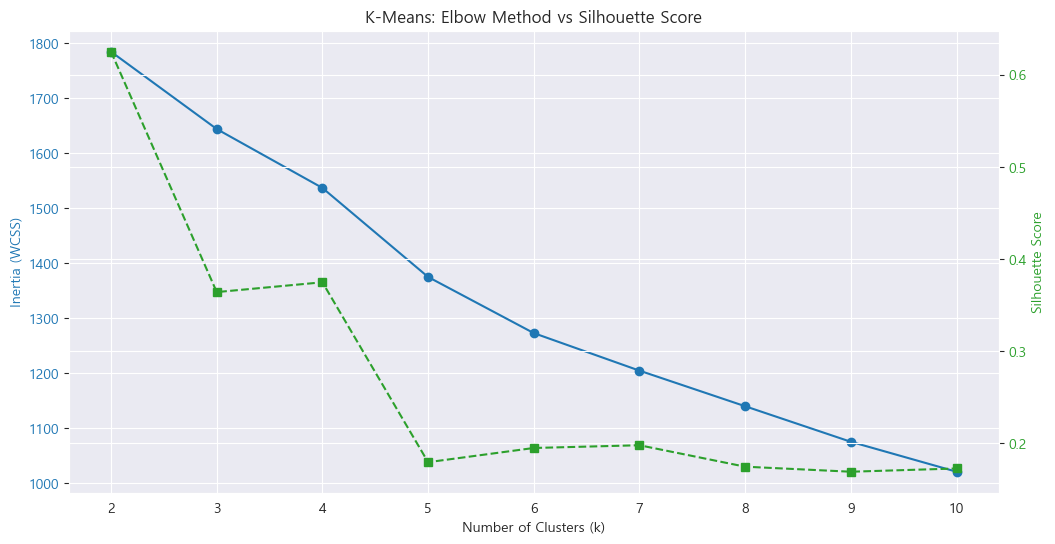

In [6]:
find_optimal_k_kmeans(df_sample, clustering_config['k_range'])

In [7]:
df_sample_clustered = perform_kmeans_clustering(df_sample, 5)

--- 4b. K-Means 군집화 시작 (K=5) ---


In [ ]:
find_optimal_k_agglomerative(df_sample, clustering_config['k_range'], clustering_config['agglomerative_linkage'])

In [ ]:
df_sample_clustered = perform_agglomerative_clustering(df_sample, clustering_config['agglomerative_k'], clustering_config['agglomerative_linkage'])

--- 5. 의사결정나무 분류기 학습 및 전체 데이터 예측 ---
  >> 최적 파라미터: {'max_features': None, 'max_leaf_nodes': 20, 'min_samples_leaf': 50, 'min_samples_split': 200}


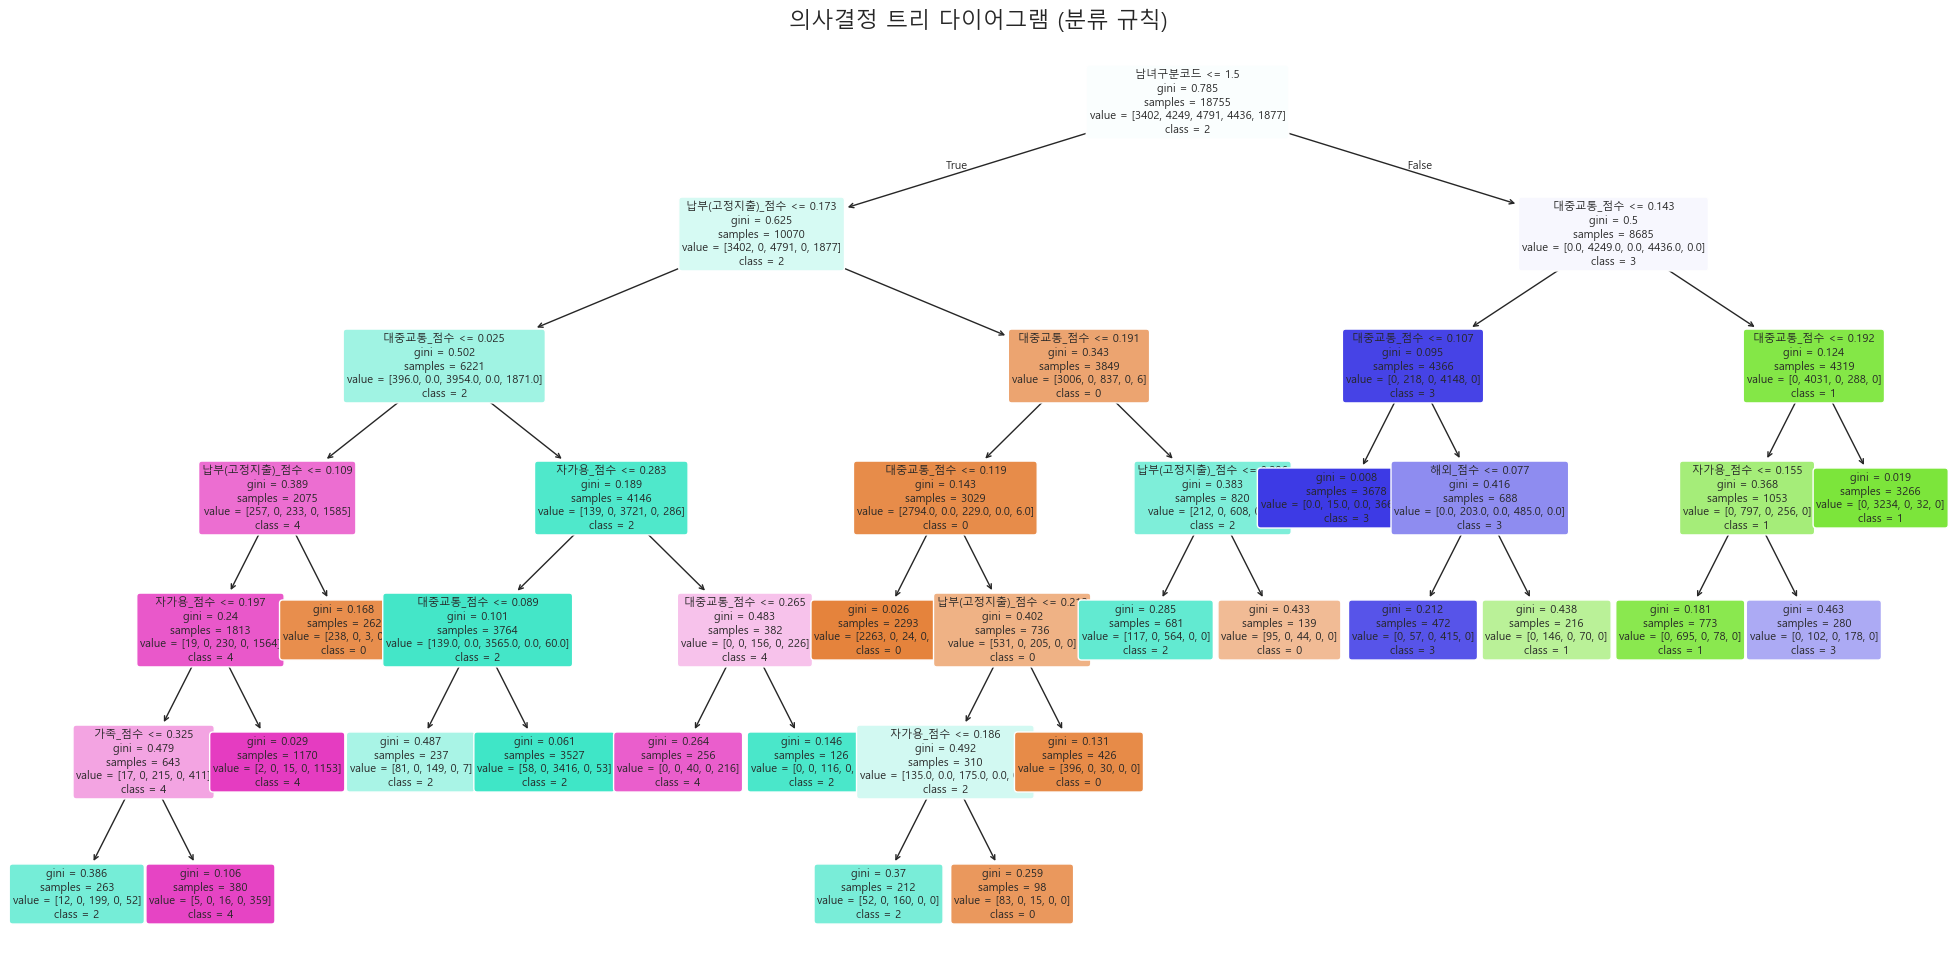

--- 6. 군집별 대표값 생성 ---
--- 7. 결과 저장 ---
  >> 전체 데이터 저장 완료: ./results\all_customer_clustered.csv
  >> 군집 대표값 저장 완료: ./results\cluster_representative.csv


=== 모든 분석 과정이 성공적으로 완료되었습니다. ===


In [8]:
# 5. 분류기를 이용한 전체 데이터 군집 할당
cluster_labels = train_and_predict_classifier(
    df_full=df_for_clustering,
    df_sample_clustered=df_sample_clustered,
    config=CONFIG
)

# 6. 최종 결과 정리
df_final = df_original.copy()
df_final['군집'] = cluster_labels

score_ratio_cols = {f"{col.replace('_점수', '')}_소비비율": col for col in CONFIG['preprocessing']['score_cols']}
for new_col, original_col in score_ratio_cols.items():
    df_final[new_col] = df_for_clustering[original_col]

# 7. 군집별 대표값 생성 및 결과 저장
df_representative = create_representative_df(df_final)
save_results(df_final, df_representative, CONFIG)

print("\n\n=== 모든 분석 과정이 성공적으로 완료되었습니다. ===")